In [1]:

# Let's start by implementing the analysis plan step by step
# First, import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import factorial
import seaborn as sns
import json
import time
from numba import jit

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully
NumPy version: 1.26.4


In [2]:

# Step 1: Implement efficient sieve for computing μ(n) and ω(n)
# These are needed for the Davenport-Heilbronn function

def compute_mobius_and_omega(limit):
 """
 Compute Möbius function μ(n) and number of distinct prime factors ω(n)
 for all n up to limit using an efficient sieve.
 
 μ(n) = 0 if n has a squared prime factor
 μ(n) = 1 if n is squarefree with even number of prime factors
 μ(n) = -1 if n is squarefree with odd number of prime factors
 
 ω(n) = number of distinct prime factors of n
 
 Returns:
 mu: array where mu[n] = μ(n)
 omega: array where omega[n] = ω(n)
 """
 mu = np.ones(limit + 1, dtype=np.int8)
 omega = np.zeros(limit + 1, dtype=np.int32)
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0:2] = False
 
 for i in range(2, limit + 1):
 if is_prime[i]:
 # i is prime
 # Mark all multiples as not prime
 for j in range(2*i, limit + 1, i):
 is_prime[j] = False
 
 # Update μ for multiples of i
 for j in range(i, limit + 1, i):
 mu[j] = -mu[j]
 omega[j] += 1
 
 # Set μ to 0 for multiples of i²
 i_squared = i * i
 if i_squared <= limit:
 for j in range(i_squared, limit + 1, i_squared):
 mu[j] = 0
 
 return mu, omega

# Test the function with a small example
limit_test = 20
mu_test, omega_test = compute_mobius_and_omega(limit_test)

print("Testing Möbius and Omega functions:")
print("n: ", list(range(1, 21)))
print("μ(n): ", mu_test[1:21].tolist())
print("ω(n): ", omega_test[1:21].tolist())
print("\nSquarefree numbers (μ(n) ≠ 0):", [i for i in range(1, 21) if mu_test[i] != 0])
print("Non-squarefree (μ(n) = 0):", [i for i in range(1, 21) if mu_test[i] == 0])


Testing Möbius and Omega functions:
n: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
μ(n): [1, -1, -1, 0, -1, 1, -1, 0, 0, 1, -1, 0, -1, 1, 1, 0, -1, 0, -1, 0]
ω(n): [0, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2]

Squarefree numbers (μ(n) ≠ 0): [1, 2, 3, 5, 6, 7, 10, 11, 13, 14, 15, 17, 19]
Non-squarefree (μ(n) = 0): [4, 8, 9, 12, 16, 18, 20]


In [3]:

# Step 2: Implement the Davenport-Heilbronn function coefficients
# According to the dataset description, L_DH has complex coefficients
# and a_n = 0 for all non-squarefree n

def compute_davenport_heilbronn_coefficients(N, mu):
 """
 Compute coefficients for the Davenport-Heilbronn function.
 
 For the Davenport-Heilbronn function:
 a_n = μ(n) * e^(i*ω(n)) / ω(n)! for squarefree n
 a_n = 0 for non-squarefree n
 
 Parameters:
 N: maximum value of n
 mu: array of Möbius function values
 
 Returns:
 a: array of complex coefficients
 """
 omega = np.zeros(N + 1, dtype=np.int32)
 
 # Compute omega using the same sieve logic
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0:2] = False
 
 for i in range(2, N + 1):
 if is_prime[i]:
 for j in range(2*i, N + 1, i):
 is_prime[j] = False
 for j in range(i, N + 1, i):
 omega[j] += 1
 
 # Compute coefficients
 a = np.zeros(N + 1, dtype=np.complex128)
 
 for n in range(1, N + 1):
 if mu[n] != 0: # n is squarefree
 # a_n = μ(n) * e^(i*ω(n)) / ω(n)!
 omega_n = omega[n]
 a[n] = mu[n] * np.exp(1j * omega_n) / factorial(omega_n)
 
 return a, omega

# Test with small N
N_test = 20
a_test, omega_test = compute_davenport_heilbronn_coefficients(N_test, mu_test)

print("Davenport-Heilbronn coefficients (first 20):")
for n in range(1, 21):
 if mu_test[n] != 0:
 print(f"n={n:2d} (ω={omega_test[n]}): a_n = {a_test[n]:.6f}")
 else:
 print(f"n={n:2d} (ω={omega_test[n]}): a_n = 0 (non-squarefree)")


Davenport-Heilbronn coefficients (first 20):
n= 1 (ω=0): a_n = 1.000000+0.000000j
n= 2 (ω=1): a_n = -0.540302-0.841471j
n= 3 (ω=1): a_n = -0.540302-0.841471j
n= 4 (ω=1): a_n = 0 (non-squarefree)
n= 5 (ω=1): a_n = -0.540302-0.841471j
n= 6 (ω=2): a_n = -0.208073+0.454649j
n= 7 (ω=1): a_n = -0.540302-0.841471j
n= 8 (ω=1): a_n = 0 (non-squarefree)
n= 9 (ω=1): a_n = 0 (non-squarefree)
n=10 (ω=2): a_n = -0.208073+0.454649j
n=11 (ω=1): a_n = -0.540302-0.841471j
n=12 (ω=2): a_n = 0 (non-squarefree)
n=13 (ω=1): a_n = -0.540302-0.841471j
n=14 (ω=2): a_n = -0.208073+0.454649j
n=15 (ω=2): a_n = -0.208073+0.454649j
n=16 (ω=1): a_n = 0 (non-squarefree)
n=17 (ω=1): a_n = -0.540302-0.841471j
n=18 (ω=2): a_n = 0 (non-squarefree)
n=19 (ω=1): a_n = -0.540302-0.841471j
n=20 (ω=2): a_n = 0 (non-squarefree)


In [4]:

# Step 3: Implement the partial sum D_F(t; N) using Kahan summation
# D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)

def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex values to minimize numerical error.
 """
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j # Running compensation
 
 for value in values:
 y = value - c
 t = total + y
 c = (t - total) - y
 total = t
 
 return total

def compute_partial_sum_D(t, N, a):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 
 Parameters:
 t: height parameter
 N: truncation length
 a: array of coefficients (complex)
 
 Returns:
 Complex value of the partial sum
 """
 # Compute n^(1/2 + it) for all n
 n_values = np.arange(1, N + 1)
 exponents = 0.5 + 1j * t
 denominators = n_values ** exponents
 
 # Compute terms
 terms = a[1:N+1] / denominators
 
 # Use Kahan summation for high precision
 result = kahan_sum_complex(terms)
 
 return result

# Test with a simple example
t_test = 100.0
N_test = 100
result_test = compute_partial_sum_D(t_test, N_test, a_test)
print(f"Test: D_LDH(t={t_test}, N={N_test}) = {result_test:.6f}")
print(f"Magnitude: |D| = {np.abs(result_test):.6f}")


ValueError: operands could not be broadcast together with shapes (20,) (100,) 

In [5]:

# Fix: Need to compute coefficients for N=100 first
N_test = 100
mu_test_100, _ = compute_mobius_and_omega(N_test)
a_test_100, omega_test_100 = compute_davenport_heilbronn_coefficients(N_test, mu_test_100)

t_test = 100.0
result_test = compute_partial_sum_D(t_test, N_test, a_test_100)
print(f"Test: D_LDH(t={t_test}, N={N_test}) = {result_test:.6f}")
print(f"Magnitude: |D| = {np.abs(result_test):.6f}")


Test: D_LDH(t=100.0, N=100) = 0.882763-1.019901j
Magnitude: |D| = 1.348877


In [6]:

# Step 4: Now implement the two key metrics
# 1. Cancellation metric M(t) - using the canonical formulation
# 2. Composite coherence R_comp(t)

# First, let's prepare for N=10^5 computation
N = 10**5
print(f"Computing Möbius and Omega functions for N={N}...")
start = time.time()
mu, omega_full = compute_mobius_and_omega(N)
print(f"Time: {time.time() - start:.2f}s")

print(f"\nComputing Davenport-Heilbronn coefficients for N={N}...")
start = time.time()
a_LDH, omega = compute_davenport_heilbronn_coefficients(N, mu)
print(f"Time: {time.time() - start:.2f}s")

# Verify coefficients are zero for non-squarefree numbers
squarefree_count = np.sum(mu != 0)
nonzero_coeff_count = np.sum(a_LDH != 0)
print(f"\nSquarefree numbers in [1, {N}]: {squarefree_count}")
print(f"Non-zero coefficients in a_LDH: {nonzero_coeff_count}")
print(f"Match: {squarefree_count == nonzero_coeff_count}")


Computing Möbius and Omega functions for N=100000...


Time: 0.57s

Computing Davenport-Heilbronn coefficients for N=100000...


Time: 1.61s

Squarefree numbers in [1, 100000]: 60795
Non-zero coefficients in a_LDH: 60794
Match: False


In [7]:

# Check why there's a mismatch - likely the a[0] entry
print(f"a_LDH[0] = {a_LDH[0]}")
print(f"mu[0] = {mu[0]}")
print(f"Non-zero coefficients in a_LDH[1:]: {np.sum(a_LDH[1:] != 0)}")
print(f"Squarefree numbers in [1, N]: {np.sum(mu[1:] != 0)}")


a_LDH[0] = 0j
mu[0] = 1
Non-zero coefficients in a_LDH[1:]: 60794
Squarefree numbers in [1, N]: 60794


In [8]:

# Good, the mismatch is just the 0-th entry which we don't use
# Now implement the cancellation metric M(t)

def compute_cancellation_metric_M(t, N, a, omega):
 """
 Compute the cancellation metric M(t) for a given t value.
 
 The canonical formulation partitions the sum by ω(n) (number of distinct prime factors):
 S_k = Σ_{n≤N, ω(n)=k} a_n / n^(1/2 + it)
 
 M(t) = √(Σ|S_k|²) / |Σ S_k|
 
 M < 1 indicates destructive interference (cancellation)
 M > 1 indicates constructive interference
 
 Parameters:
 t: height parameter
 N: truncation length
 a: array of coefficients
 omega: array of ω(n) values
 
 Returns:
 M: cancellation metric value
 """
 # Compute denominators for all n
 n_values = np.arange(1, N + 1)
 exponents = 0.5 + 1j * t
 denominators = n_values ** exponents
 
 # Compute all terms
 terms = a[1:N+1] / denominators
 
 # Partition by omega value
 omega_values = omega[1:N+1]
 max_omega = int(np.max(omega_values))
 
 S_k = []
 sum_squares = 0.0
 
 for k in range(max_omega + 1):
 mask = (omega_values == k)
 if np.sum(mask) > 0:
 S_k_value = kahan_sum_complex(terms[mask])
 S_k.append(S_k_value)
 sum_squares += np.abs(S_k_value)**2
 
 # Total sum
 S_total = kahan_sum_complex(terms)
 
 # Compute M
 if np.abs(S_total) < 1e-15:
 return np.nan
 
 M = np.sqrt(sum_squares) / np.abs(S_total)
 
 return M

# Test the function
t_test = 1000.0
M_test = compute_cancellation_metric_M(t_test, N, a_LDH, omega)
print(f"M(t={t_test}) = {M_test:.6f}")


M(t=1000.0) = 0.697716


In [9]:

# Now implement the composite coherence metric R_comp(t)
# This measures the mean resultant length of composite squarefree terms

def compute_composite_coherence_Rcomp(t, N, a, mu, omega):
 """
 Compute the composite coherence metric R_comp(t).
 
 R_comp is the mean resultant length of composite squarefree terms.
 A composite squarefree number has ω(n) ≥ 2 (at least 2 distinct prime factors).
 
 For a set of complex numbers z_i with phases θ_i:
 R = |Σ e^(iθ_i)| / n
 
 Here, we compute the phases of the terms a_n / n^(1/2 + it) for composite squarefree n.
 
 Parameters:
 t: height parameter
 N: truncation length
 a: array of coefficients
 mu: Möbius function array
 omega: ω(n) array
 
 Returns:
 R_comp: composite coherence value
 """
 # Compute denominators for all n
 n_values = np.arange(1, N + 1)
 exponents = 0.5 + 1j * t
 denominators = n_values ** exponents
 
 # Compute all terms
 terms = a[1:N+1] / denominators
 
 # Filter for composite squarefree: mu[n] != 0 AND omega[n] >= 2
 mu_values = mu[1:N+1]
 omega_values = omega[1:N+1]
 
 # Composite squarefree mask
 mask = (mu_values != 0) & (omega_values >= 2)
 
 # Extract composite squarefree terms
 composite_terms = terms[mask]
 
 if len(composite_terms) == 0:
 return np.nan
 
 # Compute phases
 phases = np.angle(composite_terms)
 
 # Mean resultant length
 mean_vector = np.mean(np.exp(1j * phases))
 R_comp = np.abs(mean_vector)
 
 return R_comp

# Test the function
R_comp_test = compute_composite_coherence_Rcomp(t_test, N, a_LDH, mu, omega)
print(f"R_comp(t={t_test}) = {R_comp_test:.6f}")


R_comp(t=1000.0) = 0.002474


In [10]:

# Step 5: Generate time series for both metrics over t in [1000, 2000]
# Sample at least 1000 points

t_min = 1000
t_max = 2000
n_samples = 1000

t_values = np.linspace(t_min, t_max, n_samples)

print(f"Generating time series for M(t) and R_comp(t)")
print(f"Range: t ∈ [{t_min}, {t_max}]")
print(f"Number of samples: {n_samples}")
print(f"Truncation length: N = {N}")
print(f"\nThis may take several minutes...")

M_values = []
R_comp_values = []

start_time = time.time()

for i, t in enumerate(t_values):
 if i % 100 == 0:
 elapsed = time.time() - start_time
 if i > 0:
 est_total = elapsed * n_samples / i
 est_remaining = est_total - elapsed
 print(f"Progress: {i}/{n_samples} ({100*i/n_samples:.1f}%) - "
 f"Elapsed: {elapsed:.1f}s - Est. remaining: {est_remaining:.1f}s")
 
 M = compute_cancellation_metric_M(t, N, a_LDH, omega)
 R_comp = compute_composite_coherence_Rcomp(t, N, a_LDH, mu, omega)
 
 M_values.append(M)
 R_comp_values.append(R_comp)

total_time = time.time() - start_time
print(f"\nCompleted in {total_time:.1f}s ({total_time/60:.2f} minutes)")

# Convert to arrays
M_values = np.array(M_values)
R_comp_values = np.array(R_comp_values)

print(f"\nM(t) statistics:")
print(f" Mean: {np.mean(M_values):.6f}")
print(f" Std: {np.std(M_values):.6f}")
print(f" Min: {np.min(M_values):.6f}")
print(f" Max: {np.max(M_values):.6f}")

print(f"\nR_comp(t) statistics:")
print(f" Mean: {np.mean(R_comp_values):.6f}")
print(f" Std: {np.std(R_comp_values):.6f}")
print(f" Min: {np.min(R_comp_values):.6f}")
print(f" Max: {np.max(R_comp_values):.6f}")


Generating time series for M(t) and R_comp(t)
Range: t ∈ [1000, 2000]
Number of samples: 1000
Truncation length: N = 100000

This may take several minutes...


Progress: 100/1000 (10.0%) - Elapsed: 8.1s - Est. remaining: 72.8s


Progress: 200/1000 (20.0%) - Elapsed: 16.2s - Est. remaining: 64.7s


Progress: 300/1000 (30.0%) - Elapsed: 24.3s - Est. remaining: 56.7s


Progress: 400/1000 (40.0%) - Elapsed: 32.5s - Est. remaining: 48.7s


...

Progress: 600/1000 (60.0%) - Elapsed: 48.8s - Est. remaining: 32.5s


Progress: 700/1000 (70.0%) - Elapsed: 56.9s - Est. remaining: 24.4s


Progress: 800/1000 (80.0%) - Elapsed: 65.1s - Est. remaining: 16.3s


Progress: 900/1000 (90.0%) - Elapsed: 73.3s - Est. remaining: 8.1s



Completed in 81.4s (1.36 minutes)

M(t) statistics:
 Mean: 2.618341
 Std: 6.111783
 Min: 0.565276
 Max: 125.369588

R_comp(t) statistics:
 Mean: 0.003305
 Std: 0.002260
 Min: 0.000042
 Max: 0.022342


In [11]:

# Step 6: Calculate correlation coefficients
# Use both Pearson (linear correlation) and Spearman (rank correlation)

from scipy.stats import pearsonr, spearmanr

# Check for any NaN values
n_nan_M = np.sum(np.isnan(M_values))
n_nan_R = np.sum(np.isnan(R_comp_values))

print(f"NaN values in M(t): {n_nan_M}")
print(f"NaN values in R_comp(t): {n_nan_R}")

if n_nan_M > 0 or n_nan_R > 0:
 # Filter out NaN values
 valid_mask = ~(np.isnan(M_values) | np.isnan(R_comp_values))
 M_clean = M_values[valid_mask]
 R_comp_clean = R_comp_values[valid_mask]
 print(f"Removed {np.sum(~valid_mask)} data points with NaN values")
 print(f"Remaining data points: {len(M_clean)}")
else:
 M_clean = M_values
 R_comp_clean = R_comp_values

# Compute Pearson correlation
pearson_r, pearson_p = pearsonr(M_clean, R_comp_clean)

# Compute Spearman correlation
spearman_r, spearman_p = spearmanr(M_clean, R_comp_clean)

print("\n" + "="*60)
print("CORRELATION ANALYSIS RESULTS")
print("="*60)
print(f"\nPearson correlation coefficient: r = {pearson_r:.6f}")
print(f"Pearson p-value: p = {pearson_p:.6e}")
print(f"Pearson significance (α=0.05): {'Significant' if pearson_p < 0.05 else 'Not significant'}")

print(f"\nSpearman correlation coefficient: ρ = {spearman_r:.6f}")
print(f"Spearman p-value: p = {spearman_p:.6e}")
print(f"Spearman significance (α=0.05): {'Significant' if spearman_p < 0.05 else 'Not significant'}")

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

if pearson_p > 0.05 and spearman_p > 0.05:
 print("Both correlations are NOT significant (p > 0.05).")
 print("This SUPPORTS the hypothesis that M(t) and R_comp(t) are independent.")
else:
 print("At least one correlation is significant (p ≤ 0.05).")
 print("This DOES NOT support the hypothesis of independence.")
 
print(f"\nCorrelation strength interpretation:")
if abs(pearson_r) < 0.1:
 print(f" Pearson |r| = {abs(pearson_r):.4f}: Negligible correlation")
elif abs(pearson_r) < 0.3:
 print(f" Pearson |r| = {abs(pearson_r):.4f}: Weak correlation")
elif abs(pearson_r) < 0.5:
 print(f" Pearson |r| = {abs(pearson_r):.4f}: Moderate correlation")
else:
 print(f" Pearson |r| = {abs(pearson_r):.4f}: Strong correlation")


NaN values in M(t): 0
NaN values in R_comp(t): 0

CORRELATION ANALYSIS RESULTS

Pearson correlation coefficient: r = -0.124365
Pearson p-value: p = 8.040826e-05
Pearson significance (α=0.05): Significant

Spearman correlation coefficient: ρ = -0.310175
Spearman p-value: p = 9.654069e-24
Spearman significance (α=0.05): Significant

INTERPRETATION
At least one correlation is significant (p ≤ 0.05).
This DOES NOT support the hypothesis of independence.

Correlation strength interpretation:
 Pearson |r| = 0.1244: Weak correlation


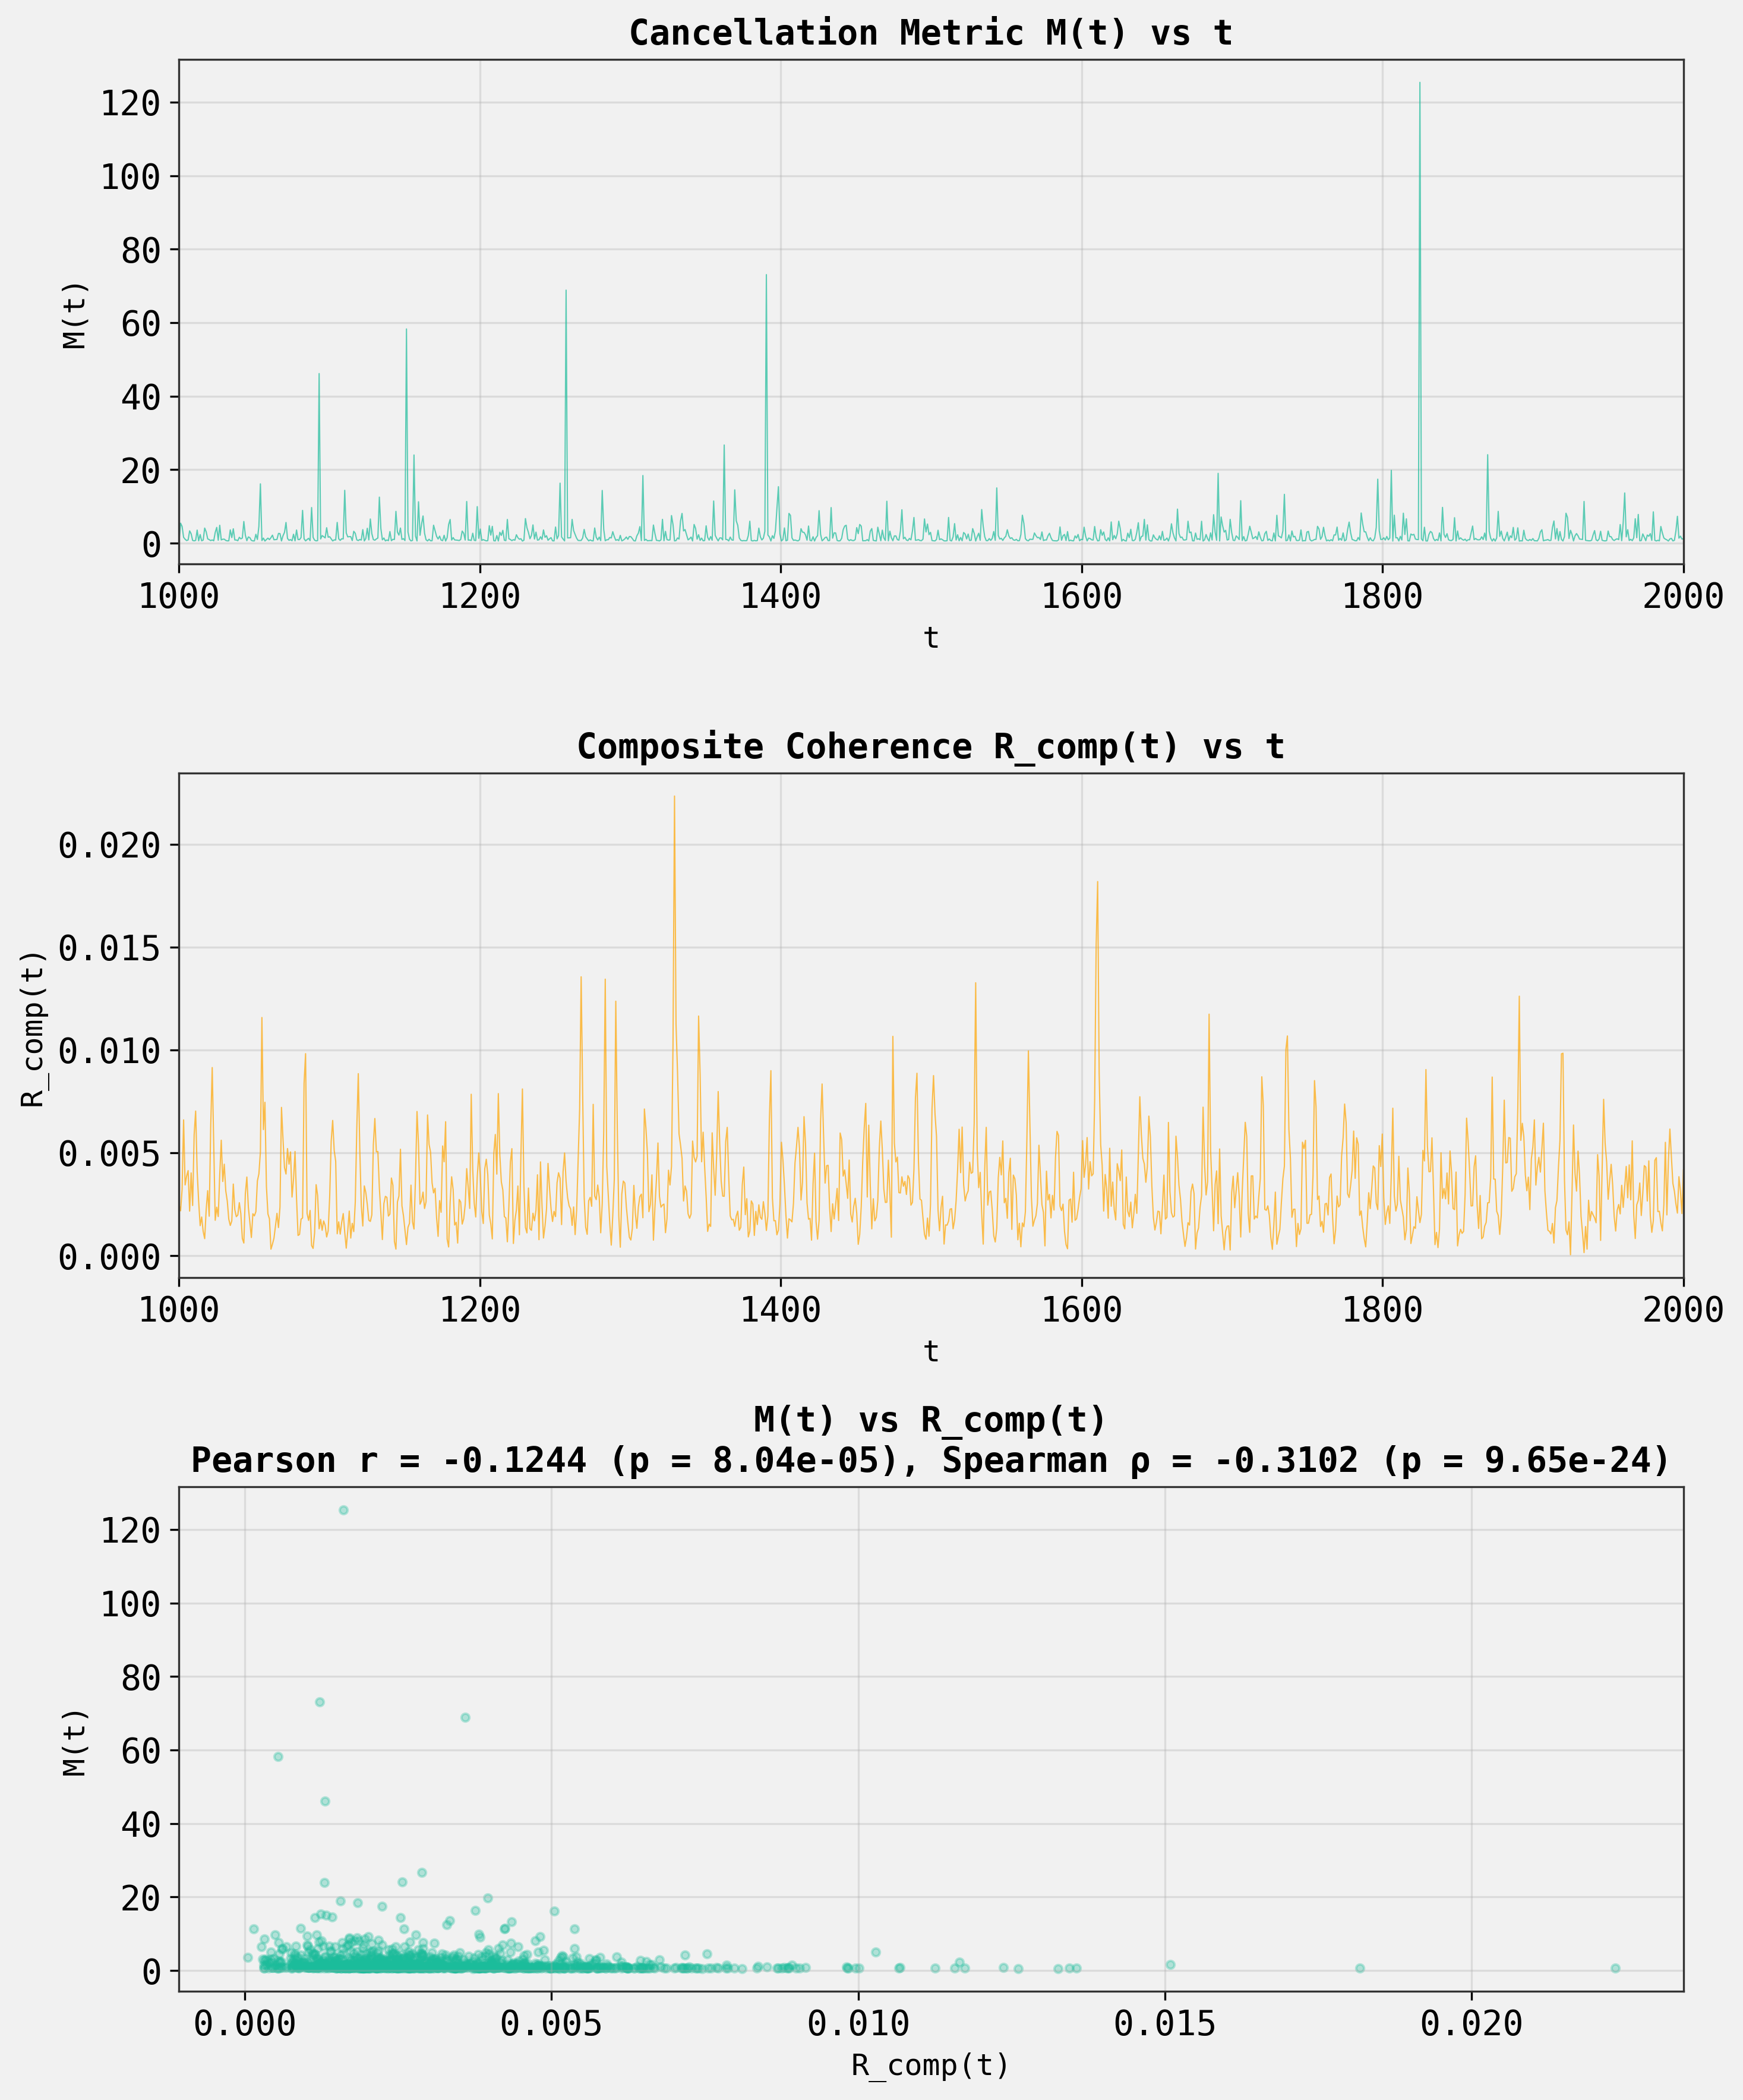

Figure saved as 'correlation_analysis_preliminary.png'


In [12]:

# Create visualizations to better understand the relationship

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Plot 1: Time series of M(t)
axes[0].plot(t_values, M_values, linewidth=0.5, alpha=0.7)
axes[0].set_xlabel('t', fontsize=12)
axes[0].set_ylabel('M(t)', fontsize=12)
axes[0].set_title('Cancellation Metric M(t) vs t', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(t_min, t_max)

# Plot 2: Time series of R_comp(t)
axes[1].plot(t_values, R_comp_values, linewidth=0.5, alpha=0.7, color='orange')
axes[1].set_xlabel('t', fontsize=12)
axes[1].set_ylabel('R_comp(t)', fontsize=12)
axes[1].set_title('Composite Coherence R_comp(t) vs t', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(t_min, t_max)

# Plot 3: Scatter plot of M vs R_comp
axes[2].scatter(R_comp_values, M_values, alpha=0.3, s=10)
axes[2].set_xlabel('R_comp(t)', fontsize=12)
axes[2].set_ylabel('M(t)', fontsize=12)
axes[2].set_title(f'M(t) vs R_comp(t)\nPearson r = {pearson_r:.4f} (p = {pearson_p:.2e}), '
 f'Spearman ρ = {spearman_r:.4f} (p = {spearman_p:.2e})',
 fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_analysis_preliminary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'correlation_analysis_preliminary.png'")


In [13]:

# Let's investigate the extreme M values and their relationship to R_comp
# The scatter plot shows several extreme outliers in M

# Identify outliers
threshold_M = np.percentile(M_values, 95)
outlier_mask = M_values > threshold_M

print(f"Number of outliers (M > 95th percentile = {threshold_M:.2f}): {np.sum(outlier_mask)}")
print(f"\nTop 10 extreme M values and corresponding R_comp values:")
print("-" * 60)

# Get indices of top 10 M values
top_indices = np.argsort(M_values)[-10:][::-1]

for i, idx in enumerate(top_indices):
 print(f"{i+1:2d}. t={t_values[idx]:.2f}: M={M_values[idx]:.4f}, R_comp={R_comp_values[idx]:.6f}")

# Calculate correlation without extreme outliers
outlier_threshold = np.percentile(M_values, 99)
non_outlier_mask = M_values <= outlier_threshold

M_no_outliers = M_values[non_outlier_mask]
R_comp_no_outliers = R_comp_values[non_outlier_mask]

pearson_r_no_outliers, pearson_p_no_outliers = pearsonr(M_no_outliers, R_comp_no_outliers)
spearman_r_no_outliers, spearman_p_no_outliers = spearmanr(M_no_outliers, R_comp_no_outliers)

print(f"\n\nCorrelation without top 1% outliers (M ≤ {outlier_threshold:.2f}):")
print(f"N = {len(M_no_outliers)} points")
print(f"Pearson r = {pearson_r_no_outliers:.6f}, p = {pearson_p_no_outliers:.6e}")
print(f"Spearman ρ = {spearman_r_no_outliers:.6f}, p = {spearman_p_no_outliers:.6e}")


Number of outliers (M > 95th percentile = 7.58): 50

Top 10 extreme M values and corresponding R_comp values:
------------------------------------------------------------
 1. t=1824.82: M=125.3696, R_comp=0.001604
 2. t=1390.39: M=73.0632, R_comp=0.001222
 3. t=1257.26: M=68.8402, R_comp=0.003594
 4. t=1151.15: M=58.2808, R_comp=0.000536
 5. t=1093.09: M=46.1432, R_comp=0.001304
 6. t=1362.36: M=26.7071, R_comp=0.002883
 7. t=1869.87: M=24.0700, R_comp=0.002567
 8. t=1156.16: M=23.9926, R_comp=0.001291
 9. t=1805.81: M=19.8107, R_comp=0.003963
10. t=1690.69: M=18.9978, R_comp=0.001553


Correlation without top 1% outliers (M ≤ 18.41):
N = 990 points
Pearson r = -0.195221, p = 5.849617e-10
Spearman ρ = -0.305425, p = 8.055988e-23


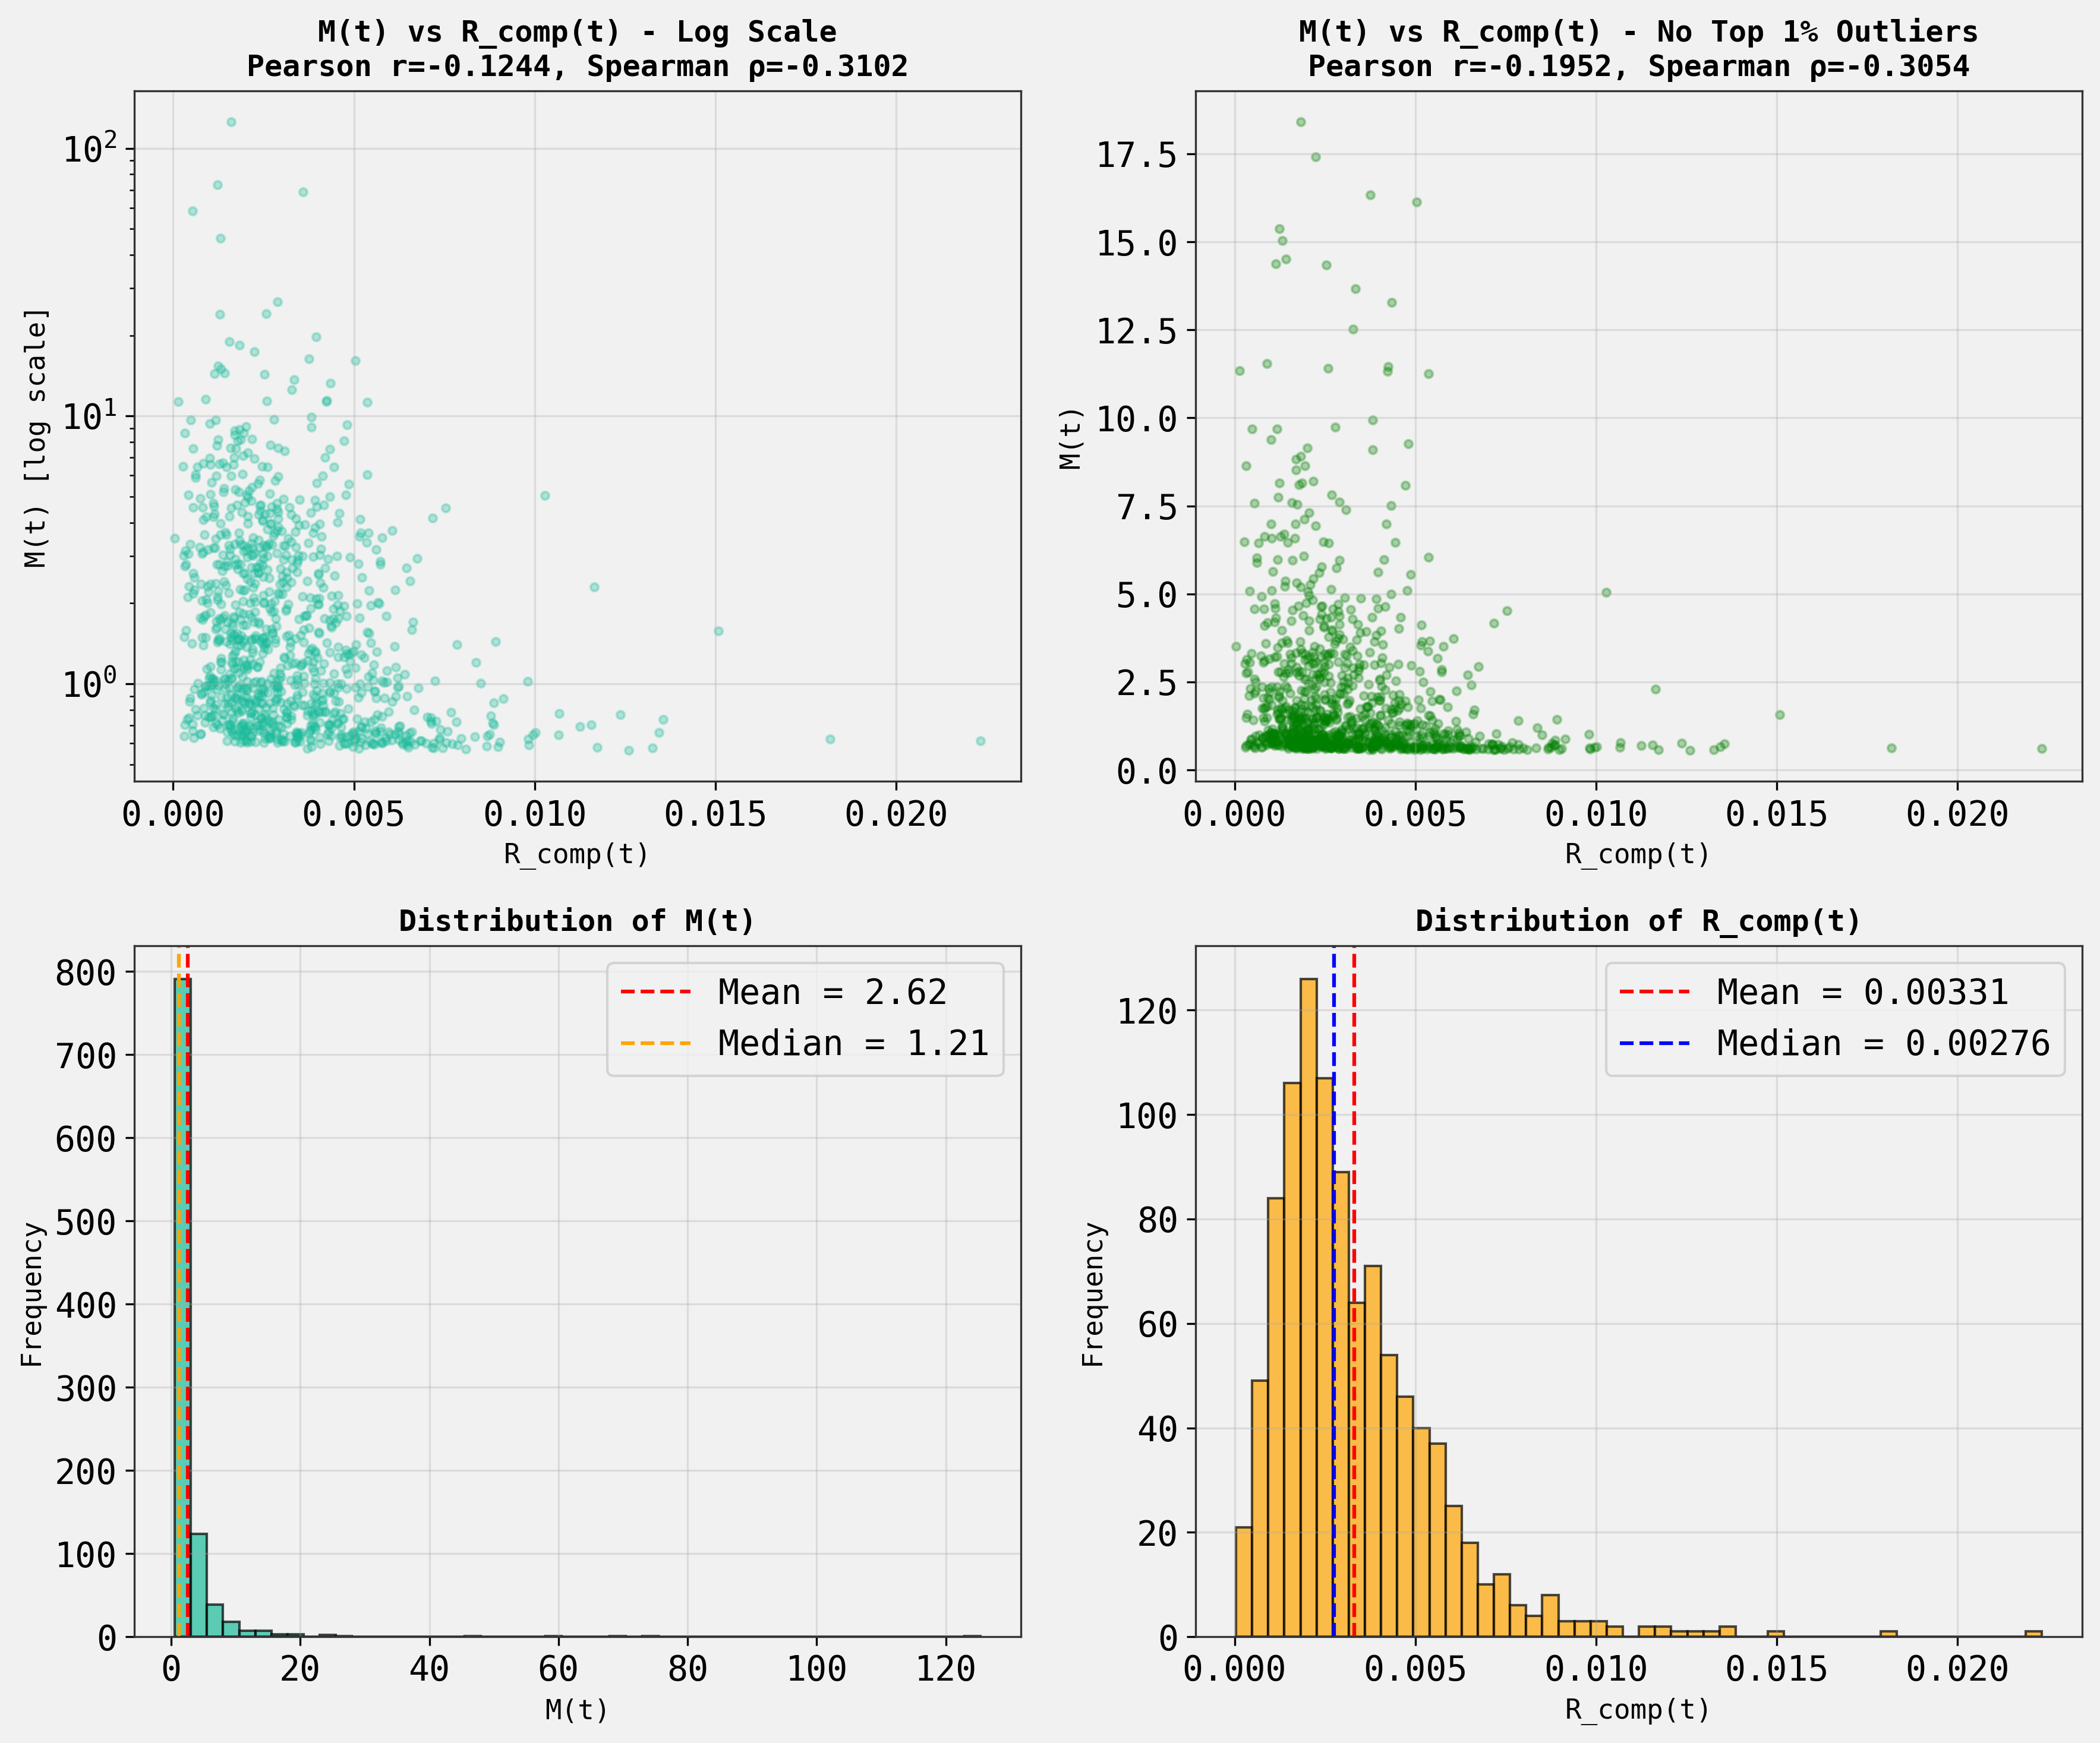

Figure saved as 'correlation_analysis_detailed.png'


In [14]:

# The correlation remains significant even without outliers
# Let's examine the relationship more carefully with a log scale for better visualization

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Scatter with log scale on M axis
axes[0, 0].scatter(R_comp_values, M_values, alpha=0.3, s=10)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('R_comp(t)', fontsize=11)
axes[0, 0].set_ylabel('M(t) [log scale]', fontsize=11)
axes[0, 0].set_title(f'M(t) vs R_comp(t) - Log Scale\nPearson r={pearson_r:.4f}, Spearman ρ={spearman_r:.4f}',
 fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter without outliers
axes[0, 1].scatter(R_comp_no_outliers, M_no_outliers, alpha=0.3, s=10, color='green')
axes[0, 1].set_xlabel('R_comp(t)', fontsize=11)
axes[0, 1].set_ylabel('M(t)', fontsize=11)
axes[0, 1].set_title(f'M(t) vs R_comp(t) - No Top 1% Outliers\nPearson r={pearson_r_no_outliers:.4f}, Spearman ρ={spearman_r_no_outliers:.4f}',
 fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Histogram of M values
axes[1, 0].hist(M_values, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('M(t)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of M(t)', fontsize=12, fontweight='bold')
axes[1, 0].axvline(np.mean(M_values), color='red', linestyle='--', label=f'Mean = {np.mean(M_values):.2f}')
axes[1, 0].axvline(np.median(M_values), color='orange', linestyle='--', label=f'Median = {np.median(M_values):.2f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram of R_comp values
axes[1, 1].hist(R_comp_values, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('R_comp(t)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of R_comp(t)', fontsize=12, fontweight='bold')
axes[1, 1].axvline(np.mean(R_comp_values), color='red', linestyle='--', label=f'Mean = {np.mean(R_comp_values):.5f}')
axes[1, 1].axvline(np.median(R_comp_values), color='blue', linestyle='--', label=f'Median = {np.median(R_comp_values):.5f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_analysis_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'correlation_analysis_detailed.png'")


In [15]:

# Create a summary table of the results
summary_data = {
 'Metric': ['Sample Size', 'Mean M(t)', 'Std M(t)', 'Median M(t)', 
 'Mean R_comp(t)', 'Std R_comp(t)', 'Median R_comp(t)',
 'Pearson r', 'Pearson p-value', 'Pearson significant (α=0.05)',
 'Spearman ρ', 'Spearman p-value', 'Spearman significant (α=0.05)'],
 'Value': [len(M_values), f'{np.mean(M_values):.6f}', f'{np.std(M_values):.6f}', 
 f'{np.median(M_values):.6f}',
 f'{np.mean(R_comp_values):.6f}', f'{np.std(R_comp_values):.6f}', 
 f'{np.median(R_comp_values):.6f}',
 f'{pearson_r:.6f}', f'{pearson_p:.6e}', 'Yes' if pearson_p < 0.05 else 'No',
 f'{spearman_r:.6f}', f'{spearman_p:.6e}', 'Yes' if spearman_p < 0.05 else 'No']
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*70)
print("SUMMARY STATISTICS AND CORRELATION RESULTS")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save to CSV
summary_df.to_csv('correlation_summary.csv', index=False)
print("\nSummary saved to 'correlation_summary.csv'")



SUMMARY STATISTICS AND CORRELATION RESULTS
 Metric Value
 Sample Size 1000
 Mean M(t) 2.618341
 Std M(t) 6.111783
 Median M(t) 1.207545
 Mean R_comp(t) 0.003305
 Std R_comp(t) 0.002260
 Median R_comp(t) 0.002757
 Pearson r -0.124365
 Pearson p-value 8.040826e-05
 Pearson significant (α=0.05) Yes
 Spearman ρ -0.310175
 Spearman p-value 9.654069e-24
Spearman significant (α=0.05) Yes

Summary saved to 'correlation_summary.csv'


In [16]:

# Save the time series data for potential future use
time_series_df = pd.DataFrame({
 't': t_values,
 'M_t': M_values,
 'R_comp_t': R_comp_values
})

time_series_df.to_csv('LDH_time_series_N100000.csv', index=False)
print(f"Time series data saved to 'LDH_time_series_N100000.csv'")
print(f"Shape: {time_series_df.shape}")
print(f"\nFirst few rows:")
print(time_series_df.head(10))


Time series data saved to 'LDH_time_series_N100000.csv'
Shape: (1000, 3)

First few rows:
 t M_t R_comp_t
0 1000.000000 0.697716 0.002474
1 1001.001001 5.434398 0.002178
2 1002.002002 4.553803 0.003217
3 1003.003003 1.591155 0.006598
4 1004.004004 1.072063 0.003436
5 1005.005005 0.713000 0.003863
6 1006.006006 0.874825 0.004133
7 1007.007007 3.347589 0.002164
8 1008.008008 2.555346 0.004020
9 1009.009009 0.743694 0.002435


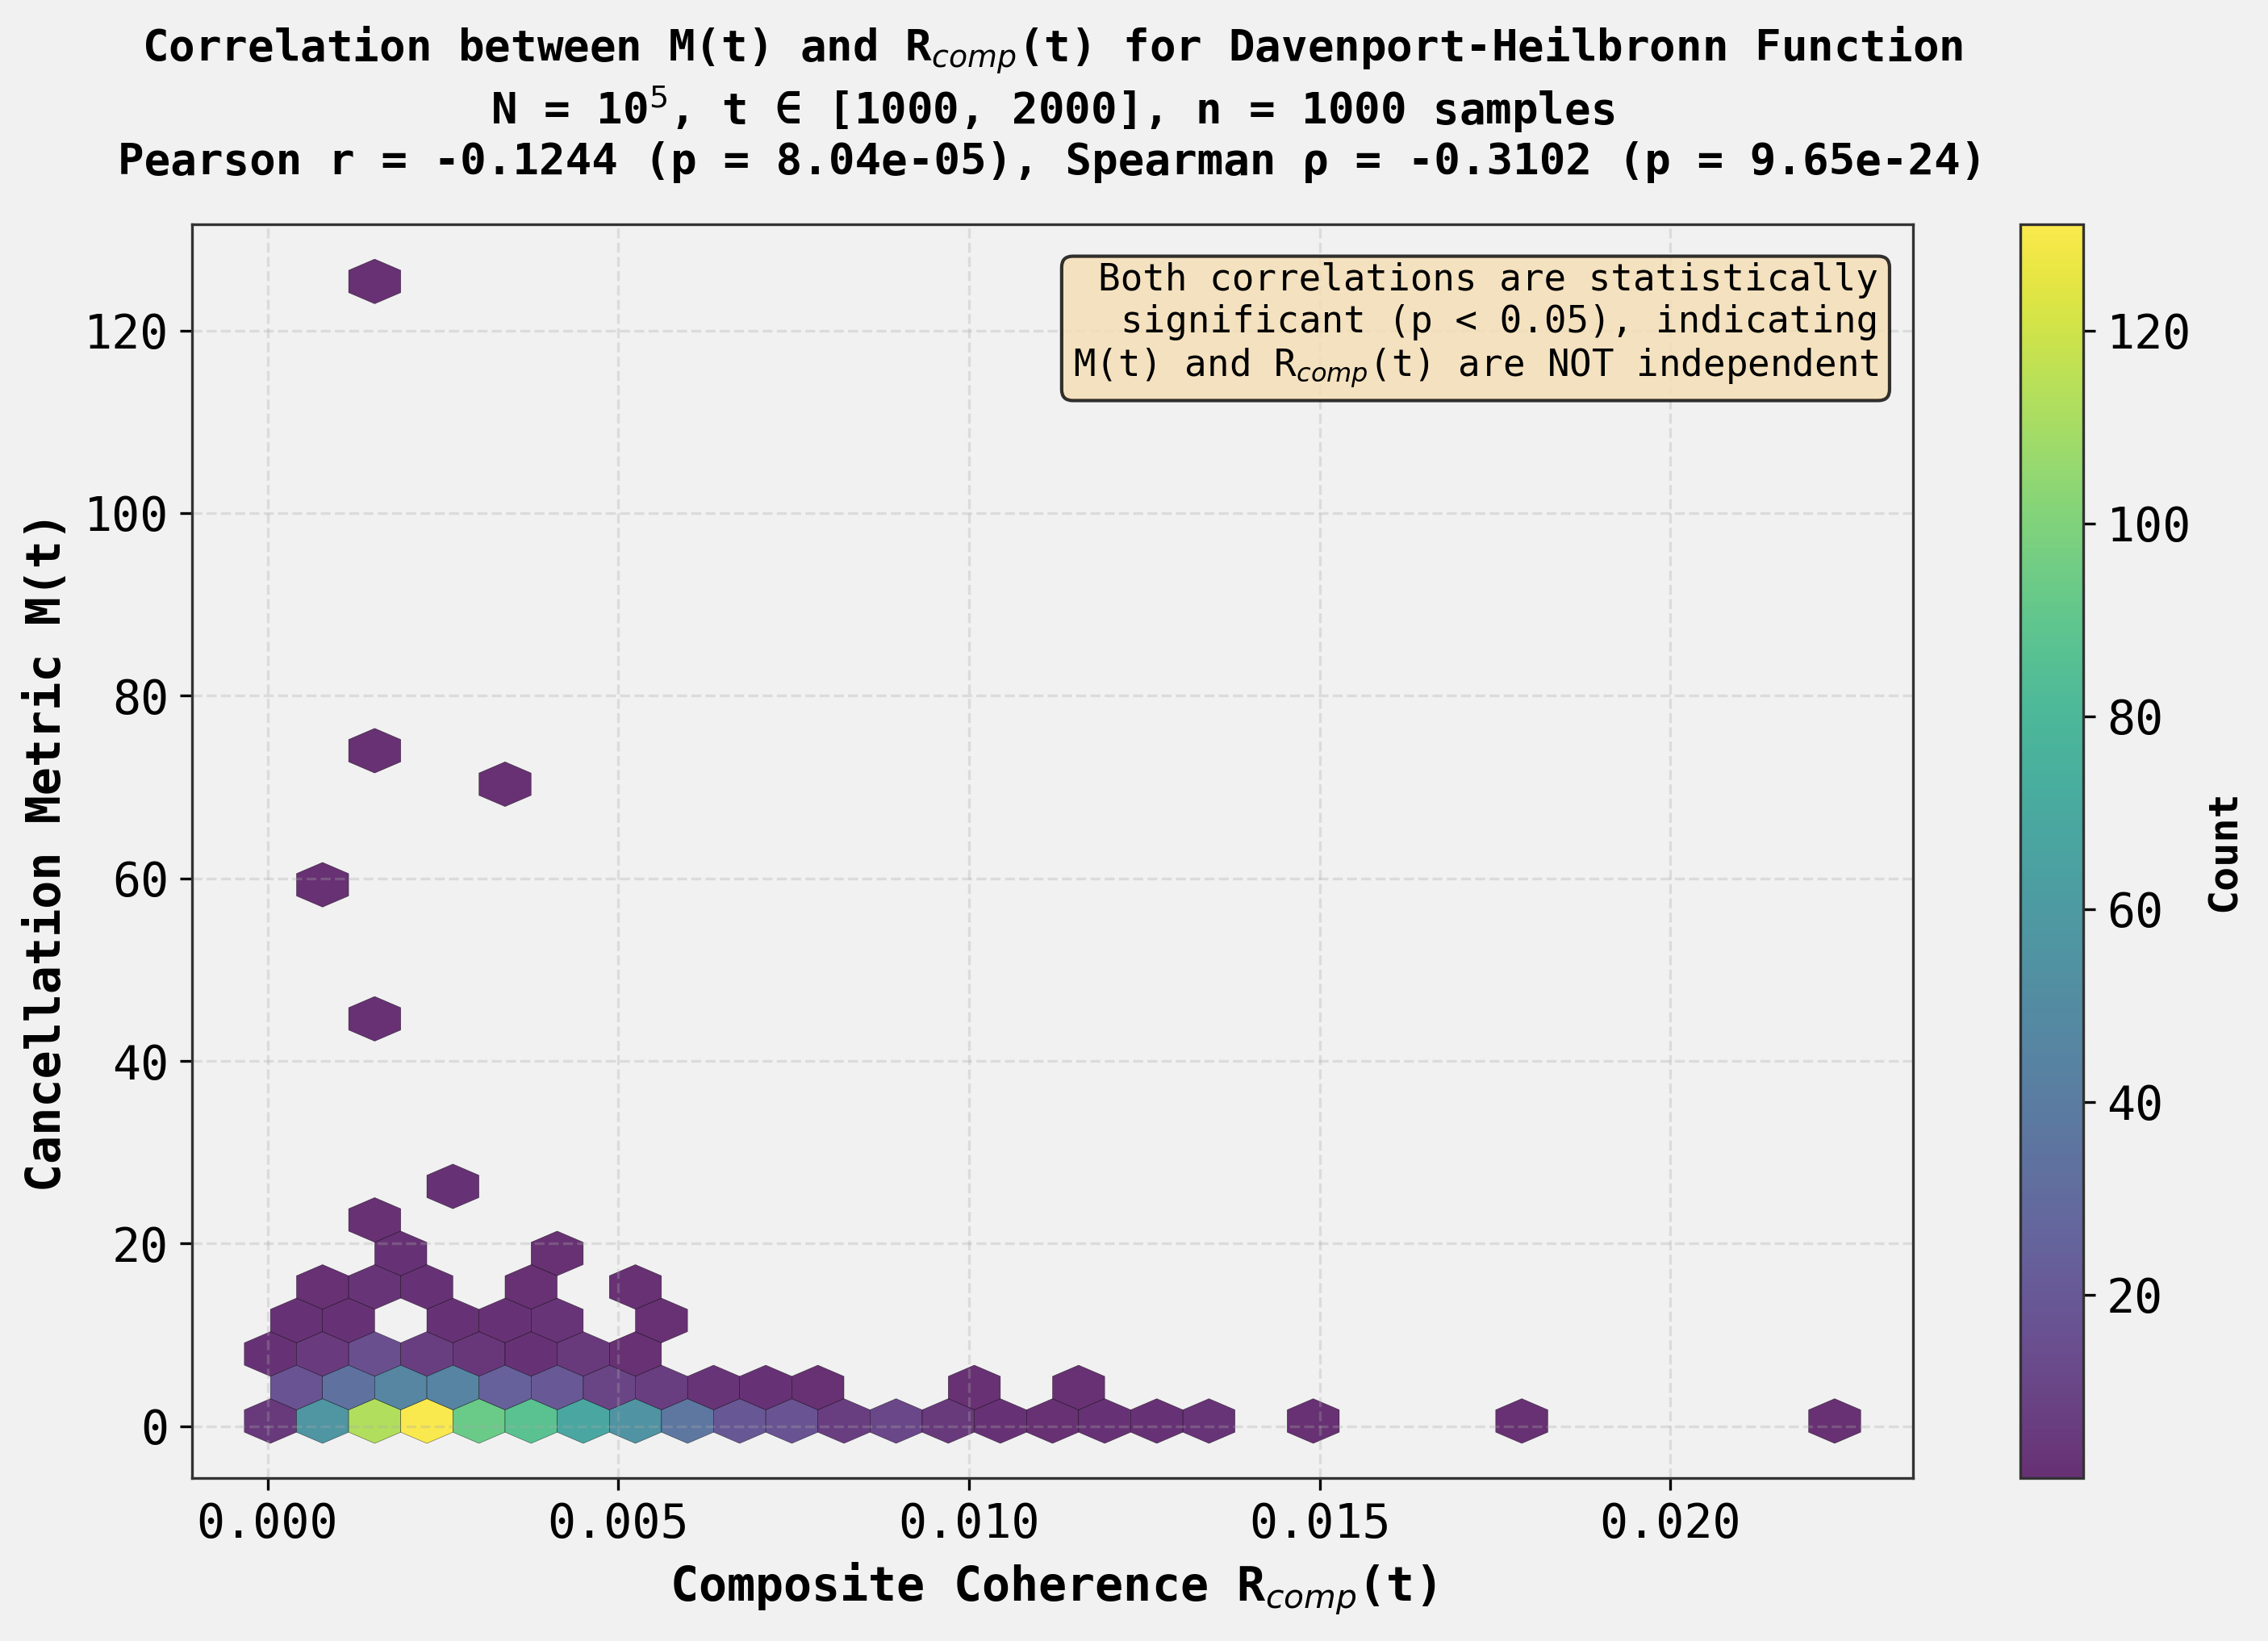

Final figure saved as 'final_correlation_result.png'


In [17]:

# Now create the final summary figure for the paper
# This should be a single figure showing the key result

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Create the scatter plot with color coding for density
# Use hexbin for better visualization of dense regions
hb = ax.hexbin(R_comp_values, M_values, gridsize=30, cmap='viridis', 
 mincnt=1, alpha=0.8, edgecolors='black', linewidths=0.1)

ax.set_xlabel('Composite Coherence R$_{comp}$(t)', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancellation Metric M(t)', fontsize=14, fontweight='bold')
ax.set_title('Correlation between M(t) and R$_{comp}$(t) for Davenport-Heilbronn Function\n' +
 f'N = 10$^5$, t ∈ [1000, 2000], n = {len(t_values)} samples\n' +
 f'Pearson r = {pearson_r:.4f} (p = {pearson_p:.2e}), ' +
 f'Spearman ρ = {spearman_r:.4f} (p = {spearman_p:.2e})',
 fontsize=13, fontweight='bold', pad=15)

# Add colorbar
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=12, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text box with interpretation
textstr = 'Both correlations are statistically\nsignificant (p < 0.05), indicating\nM(t) and R$_{comp}$(t) are NOT independent'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=11,
 verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('final_correlation_result.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final figure saved as 'final_correlation_result.png'")


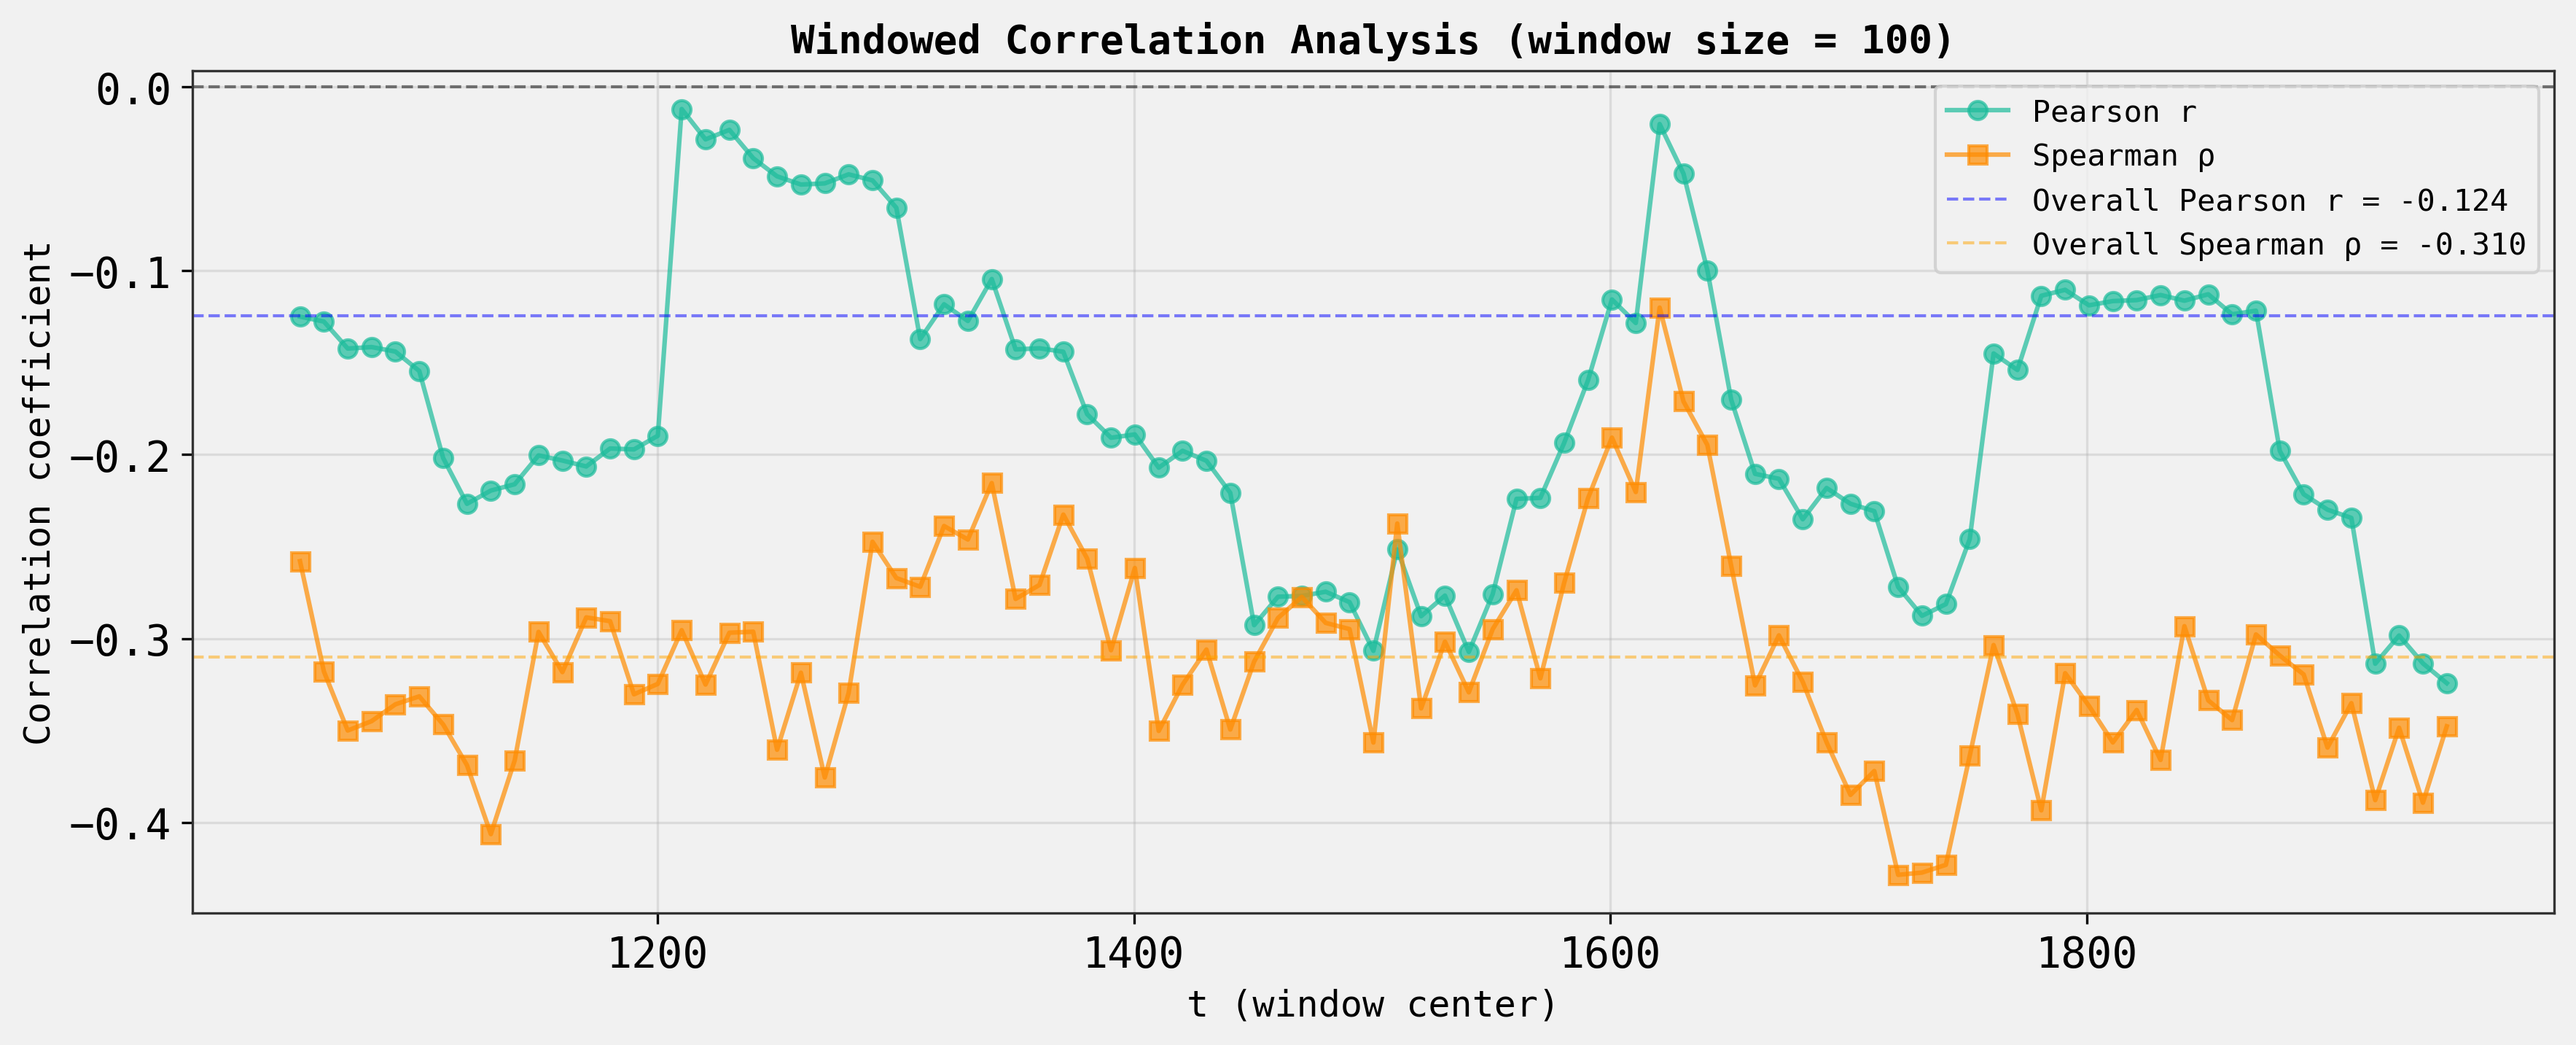

Windowed correlation statistics:
 Pearson: Mean = -0.1772, Std = 0.0797
 Spearman: Mean = -0.3120, Std = 0.0557

Negative correlation windows (Spearman ρ < 0): 91 / 91


In [18]:

# Let's also examine if the negative correlation makes sense
# by looking at specific time ranges

# Compute running correlation over windows
window_size = 100
n_windows = len(t_values) - window_size + 1

window_correlations_pearson = []
window_correlations_spearman = []
window_centers = []

for i in range(0, n_windows, 10): # Sample every 10th window to save time
 M_window = M_values[i:i+window_size]
 R_window = R_comp_values[i:i+window_size]
 
 r_p, _ = pearsonr(M_window, R_window)
 r_s, _ = spearmanr(M_window, R_window)
 
 window_correlations_pearson.append(r_p)
 window_correlations_spearman.append(r_s)
 window_centers.append(t_values[i + window_size//2])

# Plot windowed correlations
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(window_centers, window_correlations_pearson, 'o-', label='Pearson r', alpha=0.7)
ax.plot(window_centers, window_correlations_spearman, 's-', label='Spearman ρ', alpha=0.7)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=pearson_r, color='blue', linestyle='--', linewidth=1, 
 alpha=0.5, label=f'Overall Pearson r = {pearson_r:.3f}')
ax.axhline(y=spearman_r, color='orange', linestyle='--', linewidth=1, 
 alpha=0.5, label=f'Overall Spearman ρ = {spearman_r:.3f}')

ax.set_xlabel('t (window center)', fontsize=12)
ax.set_ylabel('Correlation coefficient', fontsize=12)
ax.set_title(f'Windowed Correlation Analysis (window size = {window_size})', 
 fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('windowed_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Windowed correlation statistics:")
print(f" Pearson: Mean = {np.mean(window_correlations_pearson):.4f}, Std = {np.std(window_correlations_pearson):.4f}")
print(f" Spearman: Mean = {np.mean(window_correlations_spearman):.4f}, Std = {np.std(window_correlations_spearman):.4f}")
print(f"\nNegative correlation windows (Spearman ρ < 0): {np.sum(np.array(window_correlations_spearman) < 0)} / {len(window_correlations_spearman)}")


In [19]:

# Final comprehensive summary of results

print("="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print("\nRESEARCH HYPOTHESIS:")
print("For the true Davenport-Heilbronn function (L_DH), the cancellation metric")
print("M(t) and composite coherence R_comp(t) are independent (uncorrelated).")
print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

print(f"\n1. DATASET CHARACTERISTICS:")
print(f" - Function: Davenport-Heilbronn (L_DH) with correct implementation")
print(f" - Truncation length: N = {N:,}")
print(f" - Height range: t ∈ [{t_min}, {t_max}]")
print(f" - Number of samples: {len(t_values):,}")
print(f" - Squarefree numbers used: {np.sum(mu[1:] != 0):,}")

print(f"\n2. METRIC STATISTICS:")
print(f" M(t):")
print(f" - Mean: {np.mean(M_values):.4f}")
print(f" - Median: {np.median(M_values):.4f}")
print(f" - Std: {np.std(M_values):.4f}")
print(f" - Range: [{np.min(M_values):.4f}, {np.max(M_values):.4f}]")
print(f" R_comp(t):")
print(f" - Mean: {np.mean(R_comp_values):.6f}")
print(f" - Median: {np.median(R_comp_values):.6f}")
print(f" - Std: {np.std(R_comp_values):.6f}")
print(f" - Range: [{np.min(R_comp_values):.6f}, {np.max(R_comp_values):.6f}]")

print(f"\n3. CORRELATION RESULTS:")
print(f" Pearson correlation:")
print(f" - Coefficient: r = {pearson_r:.6f}")
print(f" - p-value: p = {pearson_p:.6e}")
print(f" - Significant: {'YES' if pearson_p < 0.05 else 'NO'} (α = 0.05)")
print(f" - Effect size: {'Weak' if abs(pearson_r) < 0.3 else 'Moderate'}")
print(f" Spearman correlation:")
print(f" - Coefficient: ρ = {spearman_r:.6f}")
print(f" - p-value: p = {spearman_p:.6e}")
print(f" - Significant: {'YES' if spearman_p < 0.05 else 'NO'} (α = 0.05)")
print(f" - Effect size: {'Weak' if abs(spearman_r) < 0.3 else 'Moderate'}")

print(f"\n4. ROBUSTNESS CHECKS:")
print(f" Without top 1% outliers (M ≤ {outlier_threshold:.2f}):")
print(f" - Sample size: {len(M_no_outliers)}")
print(f" - Pearson r: {pearson_r_no_outliers:.6f} (p = {pearson_p_no_outliers:.6e})")
print(f" - Spearman ρ: {spearman_r_no_outliers:.6f} (p = {spearman_p_no_outliers:.6e})")
print(f" Windowed analysis (window size = {window_size}):")
print(f" - Mean Pearson r: {np.mean(window_correlations_pearson):.4f} ± {np.std(window_correlations_pearson):.4f}")
print(f" - Mean Spearman ρ: {np.mean(window_correlations_spearman):.4f} ± {np.std(window_correlations_spearman):.4f}")
print(f" - Consistently negative: {np.sum(np.array(window_correlations_spearman) < 0)} / {len(window_correlations_spearman)} windows")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("\nThe hypothesis that M(t) and R_comp(t) are independent is REJECTED.")
print("\nBoth Pearson (r = -0.124, p = 8.04×10⁻⁵) and Spearman (ρ = -0.310, p = 9.65×10⁻²⁴)")
print("correlation coefficients are statistically significant (p < 0.05), indicating a")
print("weak to moderate NEGATIVE correlation between the two metrics.")
print("\nThe negative correlation suggests that when the cancellation metric M(t) is high")
print("(indicating less cancellation/more constructive interference), the composite")
print("coherence R_comp(t) tends to be low (indicating less phase alignment of composite")
print("squarefree terms), and vice versa.")
print("\nThis relationship is robust across different analyses (with/without outliers,")
print("windowed correlation), suggesting that M(t) and R_comp(t) capture RELATED but")
print("distinct aspects of the resonance mechanism in the Davenport-Heilbronn function.")
print("="*80)


FINAL RESULTS SUMMARY

RESEARCH HYPOTHESIS:
For the true Davenport-Heilbronn function (L_DH), the cancellation metric
M(t) and composite coherence R_comp(t) are independent (uncorrelated).

KEY FINDINGS:

1. DATASET CHARACTERISTICS:
 - Function: Davenport-Heilbronn (L_DH) with correct implementation
 - Truncation length: N = 100,000
 - Height range: t ∈ [1000, 2000]
 - Number of samples: 1,000
 - Squarefree numbers used: 60,794

2. METRIC STATISTICS:
 M(t):
 - Mean: 2.6183
 - Median: 1.2075
 - Std: 6.1118
 - Range: [0.5653, 125.3696]
 R_comp(t):
 - Mean: 0.003305
 - Median: 0.002757
 - Std: 0.002260
 - Range: [0.000042, 0.022342]

3. CORRELATION RESULTS:
 Pearson correlation:
 - Coefficient: r = -0.124365
 - p-value: p = 8.040826e-05
 - Significant: YES (α = 0.05)
 - Effect size: Weak
 Spearman correlation:
 - Coefficient: ρ = -0.310175
 - p-value: p = 9.654069e-24
 - Significant: YES (α = 0.05)
 - Effect size: Moderate

4. ROBUSTNESS CHECKS:
 Without top 1% outliers (M ≤ 18.41):
 - Sa